# Fine-tuning EfficientNet-B0 sur GTSRB

**Modèle** : EfficientNet-B0 pré-entraîné ImageNet (~5,3M paramètres)  
**Stratégie** : Dégel partiel — gel de tout sauf `features[8]` + tête de classification remplacée (1280 → 43 classes)


## 2. Import des librairies

In [11]:

import os
import csv
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("PyTorch :", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

PyTorch : 2.10.0+cpu
Device : cpu


## 3. Téléchargement du dataset GTSRB

In [12]:
!rm -rf GTSRB
!rm -f GTSRB_Final_Training_Images.zip* GTSRB_Final_Test_Images.zip* GTSRB_Final_Test_GT.zip*

!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

!unzip -q -o GTSRB_Final_Training_Images.zip
!unzip -q -o GTSRB_Final_Test_Images.zip
!unzip -q -o GTSRB_Final_Test_GT.zip

--2026-05-21 07:03:49--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  14.8MB/s    in 21s     

2026-05-21 07:04:11 (12.4 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]

--2026-05-21 07:04:11--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[===================>]  84.8

## 4. Prétraitement

Transformations officielles EfficientNet-B0 (ImageNet) appliquées via `weights.transforms()`.


In [13]:
# Chargement des poids pré-entraînés EfficientNet-B0
weights = EfficientNet_B0_Weights.IMAGENET1K_V1

preprocess = weights.transforms()


print("Transformations :")
print(preprocess)

Transformations :
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


## 5. Chargement du dataset et split train/val

20 % du dataset, divisé en 80 % train / 20 % val.


In [14]:
data_dir = "/content/GTSRB/Final_Training/Images"

full_dataset = datasets.ImageFolder(root=data_dir, transform=preprocess)

NUM_CLASSES = len(full_dataset.classes)
print("Nombre total d'images :", len(full_dataset))
print("Nombre de classes     :", NUM_CLASSES)

Nombre total d'images : 39209
Nombre de classes     : 43


In [15]:
total_size = len(full_dataset)

subset_size = int(0.20 * total_size)
unused_size = total_size - subset_size

subset, _ = random_split(
    full_dataset,
    [subset_size, unused_size],
    generator=torch.Generator().manual_seed(42)
)

train_size = int(0.80 * len(subset))
val_size   = len(subset) - train_size

train_dataset, val_dataset = random_split(
    subset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Images d'entraînement :", len(train_dataset))
print("Images de validation  :", len(val_dataset))

Images d'entraînement : 6272
Images de validation  : 1569


In [16]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

print("Batchs train :", len(train_loader))
print("Batchs val   :", len(val_loader))

Batchs train : 98
Batchs val   : 25


## 6. Construction du modèle — Dégel partiel

Gel de toutes les couches, dégel de `features[8]` + remplacement de la tête (1280 → 43 classes).


In [17]:
# Chargement d'EfficientNet-B0 avec les poids ImageNet
model = efficientnet_b0(weights=weights)

# Gel de toutes les couches
for param in model.parameters():
    param.requires_grad = False

# Dégel du dernier bloc MBConv (features[8])
for name, param in model.named_parameters():
    if name.startswith("features.8"):
        param.requires_grad = True

# Remplacement de la tête : Linear(1280, 1000) -> Linear(1280, 43)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

model = model.to(device)

# Vérification des paramètres entraînables
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {trainable:,} / {total:,} ({100*trainable/total:.1f} %)")


Paramètres entraînables : 467,243 / 4,062,631 (11.5 %)


## 7. Fonctions d'entraînement et d'évaluation

In [18]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

## 8. Entraînement — 13 epochs, lr=1e-3, Adam, CrossEntropyLoss


In [19]:
num_epochs = 13
LR         = 1e-3

criterion = nn.CrossEntropyLoss()

#
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

# Sauvegarde
torch.save(model.state_dict(), "efficientnet_b0_gtsrb.pth")
print("Modèle sauvegardé et téléchargé.")

Epoch [1/13]
Train Loss: 1.8438 | Train Acc: 0.5349
Val   Loss: 0.9907 | Val   Acc: 0.7189
--------------------------------------------------
Epoch [2/13]
Train Loss: 0.7526 | Train Acc: 0.8021
Val   Loss: 0.6170 | Val   Acc: 0.8056
--------------------------------------------------
Epoch [3/13]
Train Loss: 0.4689 | Train Acc: 0.8803
Val   Loss: 0.4901 | Val   Acc: 0.8509
--------------------------------------------------
Epoch [4/13]
Train Loss: 0.3401 | Train Acc: 0.9125
Val   Loss: 0.4242 | Val   Acc: 0.8744
--------------------------------------------------
Epoch [5/13]
Train Loss: 0.2469 | Train Acc: 0.9396
Val   Loss: 0.3653 | Val   Acc: 0.8897
--------------------------------------------------
Epoch [6/13]
Train Loss: 0.2008 | Train Acc: 0.9539
Val   Loss: 0.3377 | Val   Acc: 0.8974
--------------------------------------------------
Epoch [7/13]
Train Loss: 0.1646 | Train Acc: 0.9636
Val   Loss: 0.3197 | Val   Acc: 0.9025
--------------------------------------------------
Epoch 

## 9. Visualisation des performances


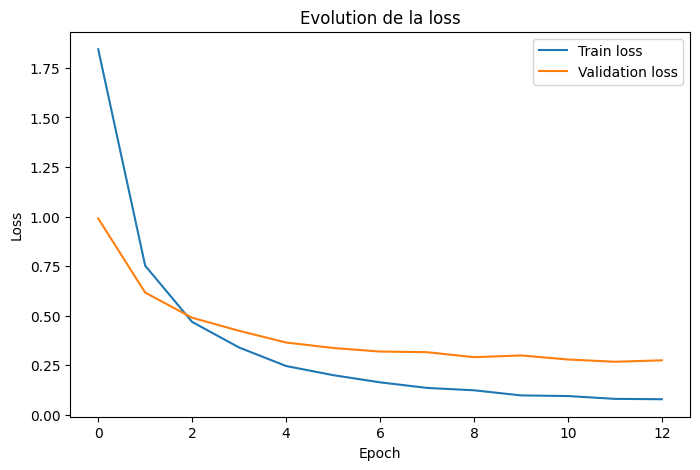

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss")
plt.legend()
plt.show()

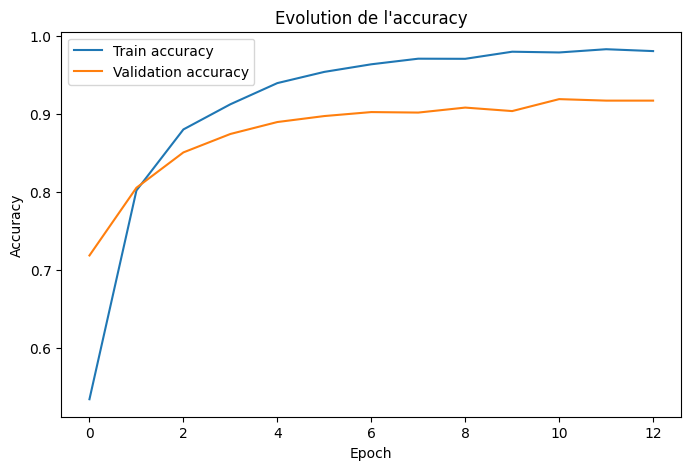

Meilleure val accuracy : 0.9191


In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(val_accuracies,   label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolution de l'accuracy")
plt.legend()
plt.show()

print(f"Meilleure val accuracy : {max(val_accuracies):.4f}")

## 10. Inférence sur le dataset de test

Avant cette étape, importer `efficientnet_b0_gtsrb.pth` dans Colab.

Le modèle doit être ici :
```text
/content/efficientnet_b0_gtsrb.pth
```


In [23]:
import os, csv, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights     = EfficientNet_B0_Weights.IMAGENET1K_V1
preprocess  = weights.transforms()
NUM_CLASSES = 43
batch_size  = 64

model = efficientnet_b0(weights=weights)
for param in model.parameters():
    param.requires_grad = False
for name, param in model.named_parameters():
    if name.startswith("features.8"):
        param.requires_grad = True
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load("efficientnet_b0_gtsrb.pth", map_location=device))
model = model.to(device)
model.eval()
print("Modèle chargé avec succès.")


Modèle chargé avec succès.


In [24]:
import os, csv
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights     = EfficientNet_B0_Weights.IMAGENET1K_V1
preprocess  = weights.transforms()
NUM_CLASSES = 43
batch_size  = 64



criterion = nn.CrossEntropyLoss()

def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total






class GTSRBTestDataset(Dataset):
    """Dataset de test GTSRB chargé depuis le CSV ground-truth officiel."""

    def __init__(self, images_dir, gt_csv_path, transform=None):
        self.images_dir = images_dir
        self.transform  = transform
        self.samples    = []
        with open(gt_csv_path, newline="") as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                self.samples.append((row["Filename"], int(row["ClassId"])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, filename)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


test_dataset = GTSRBTestDataset(
    images_dir="/content/GTSRB/Final_Test/Images",
    gt_csv_path="/content/GT-final_test.csv",
    transform=preprocess
)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Images de test :", len(test_dataset))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


# Collecte des prédictions, labels et images pour la section 11
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(preds.cpu().numpy())

print(f"Prédictions collectées : {len(all_predictions)}")

Images de test : 12630
Test Loss     : 0.6592
Test Accuracy : 0.8136
Prédictions collectées : 12630


## 11. Analyse des erreurs de prédiction


In [ ]:
import numpy as np
import pandas as pd

# Noms des classes GTSRB (43 classes)
CLASS_NAMES = [
    "Limite 20", "Limite 30", "Limite 50", "Limite 60", "Limite 70",
    "Limite 80", "Fin 80", "Limite 100", "Limite 120", "Dépassement interdit",
    "Dépassement PL interdit", "Priorité carrefour", "Route prioritaire", "Cédez le passage", "Stop",
    "Circulation interdite", "PL interdit", "Entrée interdite", "Danger", "Virage gauche",
    "Virage droit", "Succession de virages", "Dos d'âne", "Glissière", "Route rétrécie droite",
    "Travaux", "Feux tricolores", "Piétons", "Enfants", "Cyclistes",
    "Verglas", "Animaux", "Danger divers", "Fin dépassement interdit", "Fin dépassement PL",
    "Priorité à droite", "Sens unique", "Impasse", "Voie directe", "Voie gauche obligatoire",
    "Voie droite obligatoire", "Rond-point", "Fin des interdictions"
]

all_labels_np      = np.array(all_labels)
all_predictions_np = np.array(all_predictions)

# Indices des erreurs
error_mask    = all_labels_np != all_predictions_np
error_indices = np.where(error_mask)[0]

total_errors  = error_mask.sum()
total_samples = len(all_labels_np)
error_rate    = total_errors / total_samples

print(f"Total images évaluées : {total_samples}")
print(f"Erreurs totales       : {total_errors}")
print(f"Taux d'erreur         : {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Accuracy              : {1 - error_rate:.4f} ({(1-error_rate)*100:.2f}%)")


In [ ]:
# --- Top 15 des paires de classes les plus confondues ---
import pandas as pd


cm = confusion_matrix(all_labels_np, all_predictions_np)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

confusion_pairs = []
for true_cls in range(43):
    for pred_cls in range(43):
        if true_cls != pred_cls and cm[true_cls, pred_cls] > 0:
            confusion_pairs.append({
                "Vraie classe": f"{true_cls} — {CLASS_NAMES[true_cls]}",
                "Prédite comme": f"{pred_cls} — {CLASS_NAMES[pred_cls]}",
                "Nb erreurs": cm[true_cls, pred_cls],
                "Taux confusion": f"{cm_normalized[true_cls, pred_cls]*100:.1f}%"
            })

df_confusion = pd.DataFrame(confusion_pairs).sort_values("Nb erreurs", ascending=False)
print("=== Top 15 des confusions les plus fréquentes ===")
print(df_confusion.head(15).to_string(index=False))


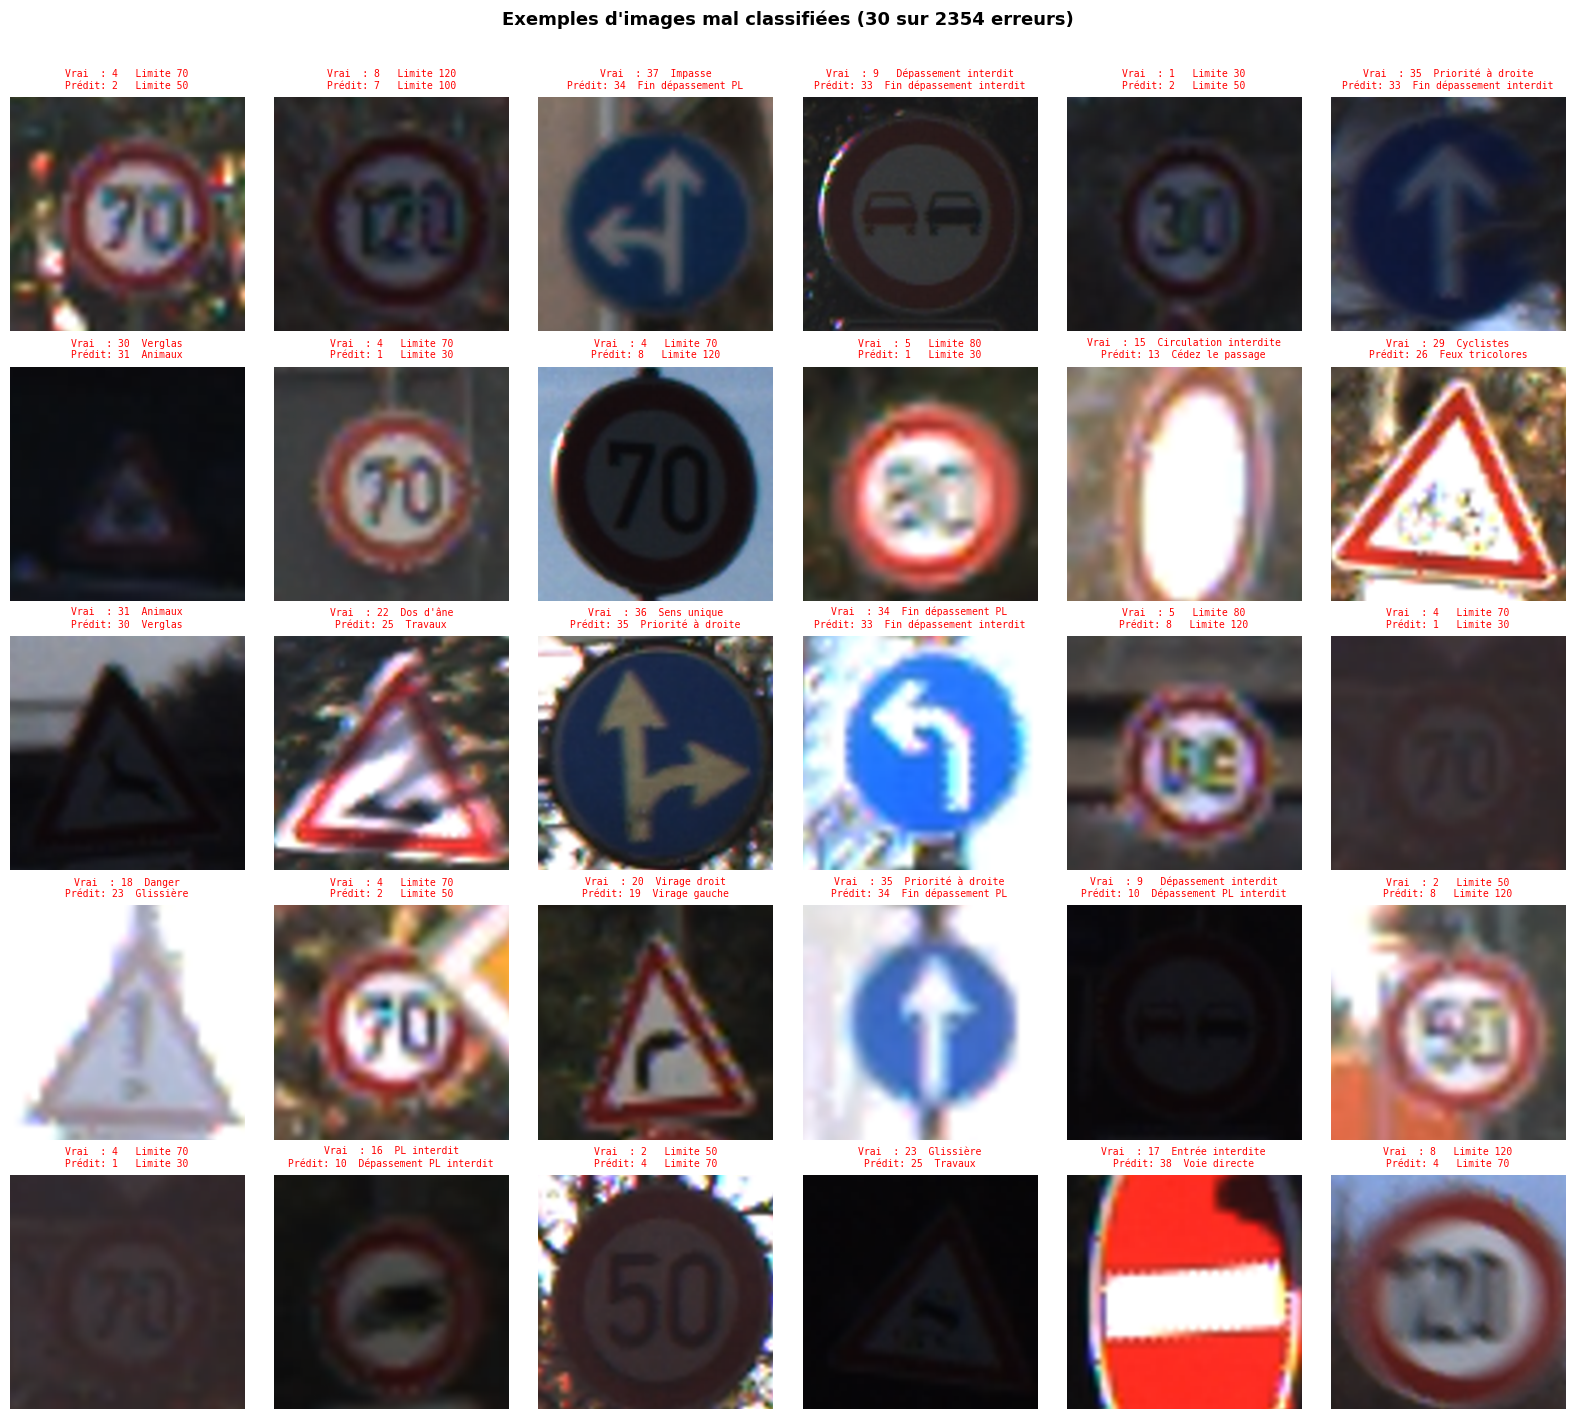

In [27]:
# --- Visualisation des images mal classifiées ---

def denormalize_imagenet(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

n_show       = min(30, len(error_indices))
sample_indices = np.random.choice(error_indices, n_show, replace=False)

cols = 6
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2.8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img, _ = test_dataset[idx]
    img = denormalize_imagenet(img)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    true_cls = all_labels_np[idx]
    pred_cls = all_predictions_np[idx]

    axes[i].imshow(img)
    axes[i].set_title(
        f"Vrai  : {true_cls:<3} {CLASS_NAMES[true_cls]}\n"
        f"Prédit: {pred_cls:<3} {CLASS_NAMES[pred_cls]}",
        fontsize=7, color="red", fontfamily="monospace"
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Exemples d'images mal classifiées ({n_show} sur {total_errors} erreurs)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
